# Convolutional Neural Network



## Import Libraries

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()

while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: d:\CompSCI_ITB\Materi\Semester_6\ML\Tubes\Tubes2\Tugas-Besar-ML-2


In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import tensorflow as tf
from src.cnn.scratch_layers_cnn import MaxPooling2D, Flatten, LocallyConnected2D
from src.cnn.keras_layers import KerasLocallyConnected2D
from src.cnn.keras_models import build_baseline_cnn, build_local_cnn
from src.common.dense import Dense
from src.cnn.weight_loader_cnn import build_scratch_from_keras_model
from src.common.image_utils import load_image
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from pathlib import Path
import json


from src.common.image_utils import load_image, load_images, list_image_paths_by_class


## Import Dataset

Jumlah train image: 14034
Class names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
(150, 150, 3)
0.0 1.0


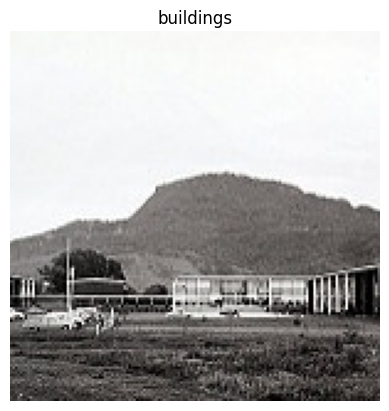

In [3]:
TRAIN_DIR = Path("../../data/raw/intel_image_classification/seg_train")
TEST_DIR = Path("../../data/raw/intel_image_classification/seg_test")

train_paths, train_labels, class_names = list_image_paths_by_class(TRAIN_DIR)

print("Jumlah train image:", len(train_paths))
print("Class names:", class_names)

img = load_image(train_paths[0], target_size=(150, 150))

print(img.shape)
print(img.min(), img.max())

plt.imshow(img)
plt.title(class_names[train_labels[0]])
plt.axis("off")
plt.show()

In [4]:
test_paths, test_labels, class_names = list_image_paths_by_class(TEST_DIR)

print("Jumlah test image:", len(test_paths))
print("Class names:", class_names)

from collections import Counter
print(Counter(test_labels))

Jumlah test image: 3000
Class names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Counter({2: 553, 3: 525, 4: 510, 5: 501, 1: 474, 0: 437})


---
# 1. Exploratory Data Analysis (EDA)



### 1.1 Distribusi Sampel per Kelas



### 1.2 Variasi Dimensi Gambar dan Aspect Ratio



### 1.3 Distribusi Intensitas Nilai Piksel per Kelas



---
# 2. Data Cleaning and Preprocessing



### 2.1 [Wajib] Resizing dan Normalisasi Gambar

Lakukan *resizing* gambar ke dimensi yang konsisten (224×224 untuk AlexNet) dan normalisasi nilai piksel. Justifikasikan pilihan Anda berdasarkan distribusi fitur yang ditemukan di EDA.

### 2.2 [Wajib] Pembagian Dataset

Split the dataset into **training set, validation set, and test set** with reasonable proportions. This is done before augmentation to **avoid data leakage**.

### 2.3 [Opsional] Preprocessing Tambahan

Langkah tambahan jika relevan berdasarkan EDA:
- Penanganan outlier jika ditemukan gambar yang rusak, tidak relevan, atau memiliki pencahayaan ekstrem.
- Data augmentation seperti *horizontal flip*, rotasi, atau *brightness adjustment* untuk memperkaya variasi dataset.

*Justification: ...*

### Helper: Custom Dataset Class

### Helper: Training and Evaluation Functions

---
# 3. Modeling and Validation



## 3.1 Baseline CNN Keras



In [5]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
NUM_CLASSES = 6


train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

class_names = train_ds.class_names
print(class_names)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.
['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [6]:
normalization = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization(x), y))
val_ds = val_ds.map(lambda x, y: (normalization(x), y))
test_ds = test_ds.map(lambda x, y: (normalization(x), y))

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [7]:
def build_baseline_cnn(input_shape=(150, 150, 3), num_classes=6):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, kernel_size=(3, 3), padding="same", activation="relu", name="conv1"),
        layers.MaxPooling2D(pool_size=(2, 2), name="pool1"),

        layers.Conv2D(64, kernel_size=(3, 3), padding="same", activation="relu", name="conv2"),
        layers.MaxPooling2D(pool_size=(2, 2), name="pool2"),

        layers.Flatten(name="flatten"),
        layers.Dense(128, activation="relu", name="dense1"),
        layers.Dense(num_classes, activation="softmax", name="output"),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


baseline_model = build_baseline_cnn(num_classes=NUM_CLASSES)
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 87616)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │    11,214,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,235,142 (42.86 MB)

 Trainable params: 11,235,142 (42.86 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
)

Epoch 1/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 46s 128ms/step - accuracy: 0.6474 - loss: 0.9440 - val_accuracy: 0.7391 - val_loss: 0.7260
Epoch 2/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 45s 129ms/step - accuracy: 0.8017 - loss: 0.5534 - val_accuracy: 0.7766 - val_loss: 0.6216
Epoch 3/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 46s 130ms/step - accuracy: 0.8899 - loss: 0.3156 - val_accuracy: 0.7748 - val_loss: 0.7313
Epoch 4/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 48s 136ms/step - accuracy: 0.9532 - loss: 0.1490 - val_accuracy: 0.7876 - val_loss: 0.8030
Epoch 5/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 46s 132ms/step - accuracy: 0.9751 - loss: 0.0841 - val_accuracy: 0.7805 - val_loss: 0.8795


In [9]:
Path("../../models/cnn").mkdir(parents=True, exist_ok=True)
baseline_model.save("../../models/cnn/baseline_conv2d.keras")
baseline_model.save_weights("../../models/cnn/baseline_conv2d.weights.h5")

In [10]:
y_true = []
y_pred = []

for x_batch, y_batch in test_ds:
    probs = baseline_model.predict(x_batch, verbose=0)
    preds = np.argmax(probs, axis=1)

    y_true.extend(y_batch.numpy())
    y_pred.extend(preds)

macro_f1 = f1_score(y_true, y_pred, average="macro")

print("Macro F1:", macro_f1)
print(classification_report(y_true, y_pred, target_names=class_names))
print(confusion_matrix(y_true, y_pred))

Macro F1: 0.7925859161905532
              precision    recall  f1-score   support

   buildings       0.76      0.73      0.74       437
      forest       0.96      0.92      0.94       474
     glacier       0.82      0.66      0.73       553
    mountain       0.67      0.82      0.74       525
         sea       0.78      0.78      0.78       510
      street       0.80      0.84      0.82       501

    accuracy                           0.79      3000
   macro avg       0.80      0.79      0.79      3000
weighted avg       0.80      0.79      0.79      3000

[[319   3   6  19  17  73]
 [ 14 437   2   5   2  14]
 [ 13   2 363 112  56   7]
 [  9   2  49 431  31   3]
 [ 11   3  22  68 400   6]
 [ 56   8   3   5   7 422]]


---
## 3.2 Testing



In [11]:
x = np.random.rand(150, 150, 3).astype(np.float32)

pool = MaxPooling2D(pool_size=(2, 2))
out_pool = pool.forward(x)

flat = Flatten()
out_flat = flat.forward(out_pool)

print("Input:", x.shape)
print("After pooling:", out_pool.shape)
print("After flatten:", out_flat.shape)

Input: (150, 150, 3)
After pooling: (75, 75, 3)
After flatten: (16875,)


In [12]:
# 1 gambar
keras_model = tf.keras.models.load_model("../../models/cnn/baseline_conv2d.keras")
scratch_model = build_scratch_from_keras_model("../../models/cnn/baseline_conv2d.keras")

x = load_image(train_paths[0], target_size=(150, 150))

keras_prob = keras_model.predict(np.expand_dims(x, axis=0), verbose=0)[0]
scratch_prob = scratch_model.forward(x)

print("Keras pred:", np.argmax(keras_prob))
print("Scratch pred:", np.argmax(scratch_prob))
print("Max absolute difference:", np.max(np.abs(keras_prob - scratch_prob)))

Keras pred: 0
Scratch pred: 0
Max absolute difference: 2.910383e-09


In [13]:
# Sebanyak X batch
x_batch = load_images(train_paths[:8], target_size=(150, 150))

keras_probs = keras_model.predict(x_batch, verbose=0)
scratch_probs = scratch_model.forward(x_batch)

print("Keras probs shape:", keras_probs.shape)
print("Scratch probs shape:", scratch_probs.shape)

print("Keras preds:", np.argmax(keras_probs, axis=1))
print("Scratch preds:", np.argmax(scratch_probs, axis=1))

print("Max absolute difference:", np.max(np.abs(keras_probs - scratch_probs)))

Keras probs shape: (8, 6)
Scratch probs shape: (8, 6)
Keras preds: [0 0 0 0 0 3 0 0]
Scratch preds: [0 0 0 0 0 3 0 0]
Max absolute difference: 5.9604645e-07


In [14]:
test_paths, test_labels, class_names = list_image_paths_by_class(TEST_DIR)

test_labels = np.array(test_labels)

def predict_scratch_batched(model, image_paths, batch_size=16):
    preds = []

    for i in tqdm(range(0, len(image_paths), batch_size), desc="Scratch batch prediction"):
        batch_paths = image_paths[i:i + batch_size]
        x_batch = load_images(batch_paths, target_size=(150, 150))

        probs = model.forward(x_batch)
        preds.extend(np.argmax(probs, axis=1))

    return np.array(preds)


scratch_preds = predict_scratch_batched(
    scratch_model,
    test_paths,
    batch_size=16
)

Scratch batch prediction: 100%|██████████| 188/188 [00:29<00:00,  6.43it/s]


In [15]:
def predict_keras_batched(model, image_paths, batch_size=32):
    preds = []

    with tqdm(total=len(image_paths), desc="Keras image prediction") as pbar:
        for i in range(0, len(image_paths), batch_size):
            batch_paths = image_paths[i:i + batch_size]
            x_batch = load_images(batch_paths, target_size=(150, 150))

            probs = model.predict(x_batch, verbose=0)
            preds.extend(np.argmax(probs, axis=1))

            pbar.update(len(batch_paths))

    return np.array(preds)


keras_preds = predict_keras_batched(
    keras_model,
    test_paths,
    batch_size=32
)

Keras image prediction: 100%|██████████| 3000/3000 [00:09<00:00, 331.46it/s]


In [16]:
keras_macro_f1 = f1_score(test_labels, keras_preds, average="macro")
scratch_macro_f1 = f1_score(test_labels, scratch_preds, average="macro")

agreement = np.mean(keras_preds == scratch_preds)

print("Keras Macro F1:", keras_macro_f1)
print("Scratch Macro F1:", scratch_macro_f1)
print("Prediction agreement:", agreement)

print("\nKeras Classification Report")
print(classification_report(
    test_labels,
    keras_preds,
    target_names=class_names,
    zero_division=0
))

print("\nScratch Classification Report")
print(classification_report(
    test_labels,
    scratch_preds,
    target_names=class_names,
    zero_division=0
))

Keras Macro F1: 0.7934903308299761
Scratch Macro F1: 0.7934903308299761
Prediction agreement: 1.0

Keras Classification Report
              precision    recall  f1-score   support

   buildings       0.76      0.73      0.74       437
      forest       0.97      0.92      0.94       474
     glacier       0.81      0.66      0.73       553
    mountain       0.67      0.82      0.74       525
         sea       0.79      0.78      0.79       510
      street       0.80      0.85      0.83       501

    accuracy                           0.79      3000
   macro avg       0.80      0.79      0.79      3000
weighted avg       0.80      0.79      0.79      3000


Scratch Classification Report
              precision    recall  f1-score   support

   buildings       0.76      0.73      0.74       437
      forest       0.97      0.92      0.94       474
     glacier       0.81      0.66      0.73       553
    mountain       0.67      0.82      0.74       525
         sea       0.79     

In [17]:
Path("../../results/cnn").mkdir(parents=True, exist_ok=True)

np.save("../../results/cnn/test_labels.npy", test_labels)
np.save("../../results/cnn/keras_preds_baseline.npy", keras_preds)
np.save("../../results/cnn/scratch_preds_baseline.npy", scratch_preds)

baseline_result = {
    "model": "baseline_conv2d",
    "num_test_images": int(len(test_labels)),
    "keras_macro_f1": float(keras_macro_f1),
    "scratch_macro_f1": float(scratch_macro_f1),
    "prediction_agreement": float(agreement),
    "batch_inference_scratch_cnn": True,
}

with open("../../results/cnn/baseline_keras_vs_scratch.json", "w") as f:
    json.dump(baseline_result, f, indent=4)

baseline_result

{'model': 'baseline_conv2d',
 'num_test_images': 3000,
 'keras_macro_f1': 0.7934903308299761,
 'scratch_macro_f1': 0.7934903308299761,
 'prediction_agreement': 1.0,
 'batch_inference_scratch_cnn': True}

---
## 3.3 Test LocallyConnected



In [18]:
x_batch = load_images(test_paths[:8], target_size=(150, 150))

keras_local_layer = KerasLocallyConnected2D(
    filters=16,
    kernel_size=(3, 3),
    padding="same",
    activation="relu"
)

keras_out = keras_local_layer(x_batch).numpy()

local_w, local_b = keras_local_layer.get_weights()

scratch_local_layer = LocallyConnected2D(
    weights=local_w,
    bias=local_b,
    kernel_size=(3, 3),
    padding="same",
    activation="relu"
)

scratch_out = scratch_local_layer.forward(x_batch)

print("Keras output shape:", keras_out.shape)
print("Scratch output shape:", scratch_out.shape)
print("Max absolute difference:", np.max(np.abs(keras_out - scratch_out)))

Keras output shape: (8, 150, 150, 16)
Scratch output shape: (8, 150, 150, 16)
Max absolute difference: 5.5879354e-09
